In [2]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark=SparkSession.builder\
    .appName('SparkToPostgresql')\
    .config('spark.jars','E:\workspace\python_script\.venv\Lib\site-packages\pyspark\jars\postgresql-42.6.0.jar')\
    .getOrCreate()
# 连接信息（你本地的PostgreSQL）
url = 'jdbc:postgresql://localhost:5432/postgres'
table='students'
user='zhaobo'
password='1'
driver='org.postgresql.Driver'
#读取表
df=spark.read.format('jdbc')\
        .option('url',url)\
        .option('dbtable',table)\
        .option('user',user)\
        .option('password',password)\
        .option('driver',driver)\
        .load()
#查看数据
df.show()
df.printSchema()

+----------+----+---------+
|student_id|name| province|
+----------+----+---------+
|         4|小刚|  beijing|
|         3|小王|    gansu|
|         6|小杨|guangzhou|
|         2|小李|    henan|
|         5|小红| shanghai|
|         1|小明|   shanxi|
+----------+----+---------+

root
 |-- student_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- province: string (nullable = true)



In [5]:
#  写入 PostgreSQL
df1=spark.read.csv('../python基础/data/2025年中国汽车销售数据.csv',header=True,inferSchema=True)
#写入PostgreSQL
df1.write.format('jdbc')\
    .mode('overwrite')\
    .option('url',url)\
    .option("dbtable", "china_ev_sales_data_2025") \
    .option("user", user) \
    .option("password", password) \
    .option("driver", driver) \
    .save()

# Spark 读写 PostgreSQL 就 3 步：
加驱动 jar
填连接信息
read.jdbc / write.jdbc
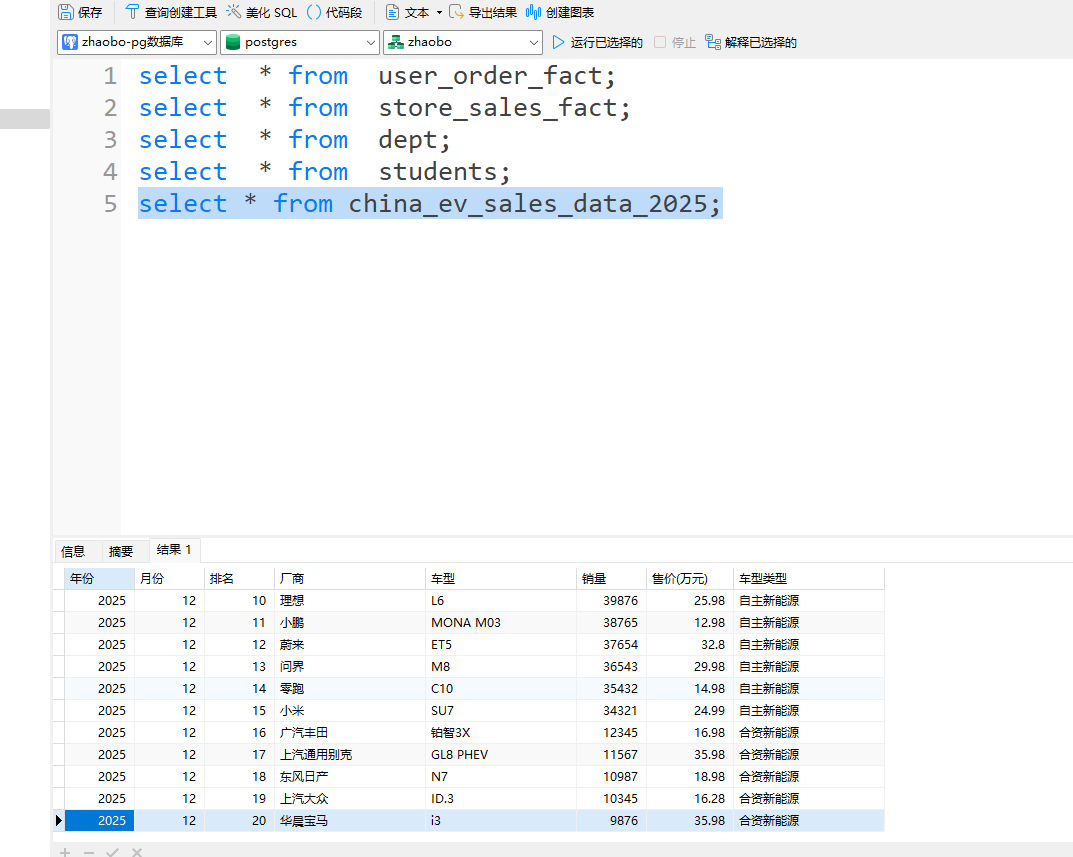

In [6]:
spark.stop()